# FTW Baseline — Result Visualization

Displays training/test results for the 3-class U-Net + EfficientNet-B3 baseline.
Set `TEST_DIR` below to point at a specific run's output folder.

In [1]:
import os
import random

import subprocess
import pandas as pd
from matplotlib.colors import ListedColormap

from ftw_tools.training.datasets import FTW

from plot_utils import (
    # run_sample_inference,
    plot_sample_predictions, 
    plot_polygonized_results, 
    plot_post_processing_results, 
    plot_polygon_size_distribution
)
random.seed(42)

## 1. Metrics Summary

In [2]:
RUN_ID = "7v9677na"
TEST_DIR = f"../outputs/test_{RUN_ID}"
METRICS_CSV = f"{TEST_DIR}/test_metrics_{RUN_ID}.csv"
CHECKPOINT_FOR_TEST = f"../wandb/{RUN_ID}/checkpoints/epoch=84-val/iou=0.000.ckpt"
DATA_DIR = "../data/ftw"

os.makedirs(TEST_DIR, exist_ok=True)
if not os.path.exists(METRICS_CSV):
    if not os.path.exists(CHECKPOINT_FOR_TEST):
        print(f"Checkpoint not found: {CHECKPOINT_FOR_TEST}")
    else:
        result = subprocess.run(
            [
                "ftw", "model", "test",
                "-m", CHECKPOINT_FOR_TEST,
                "--dir", DATA_DIR,
                "-c", "austria",
                "-p3", "-t3",
                "--gpu=-1",
                "-o", METRICS_CSV,
            ],
            capture_output=True, text=True,
            encoding="utf-8", errors="replace",
        )
        print(result.stdout)
        if result.returncode != 0:
            print("STDERR:\n", result.stderr)

try:
    df = pd.read_csv(METRICS_CSV)
    display(df.T)
except FileNotFoundError:
    print(f"Metrics file not found: {METRICS_CSV}")

,0
train_checkpoint,../wandb/7v9677na/checkpoints/epoch=84-val/iou...
countries,austria
pixel_level_iou,0.726111
pixel_level_precision,0.845778
pixel_level_recall,0.836921
object_level_precision,0.521526
object_level_recall,0.341582
object_level_f1,0.412796


## 2. Sample Patch Predictions

Loads individual 256x256 Austria test patches, stacks window_b + window_a, and runs
`inference_run` (same code path as `ftw inference run`) on each.

In [3]:
N_SAMPLES = 6
CMAP = ListedColormap(
    ["#888888", "#4CAF50", "#F44336", "#000000"]
    )

ds = FTW(
    root=DATA_DIR, 
    countries=["austria"], 
    split="test", 
    load_boundaries=True
    )
indices = random.sample(
    range(len(ds)), min(N_SAMPLES, len(ds))
    )
print(f"Selected {len(indices)} samples")

Loading 3 Class Masks, with Boundaries
Temporal option:  stacked
Using window B first, then window A
Selecting: 745 samples (split=test)
Selected 6 samples


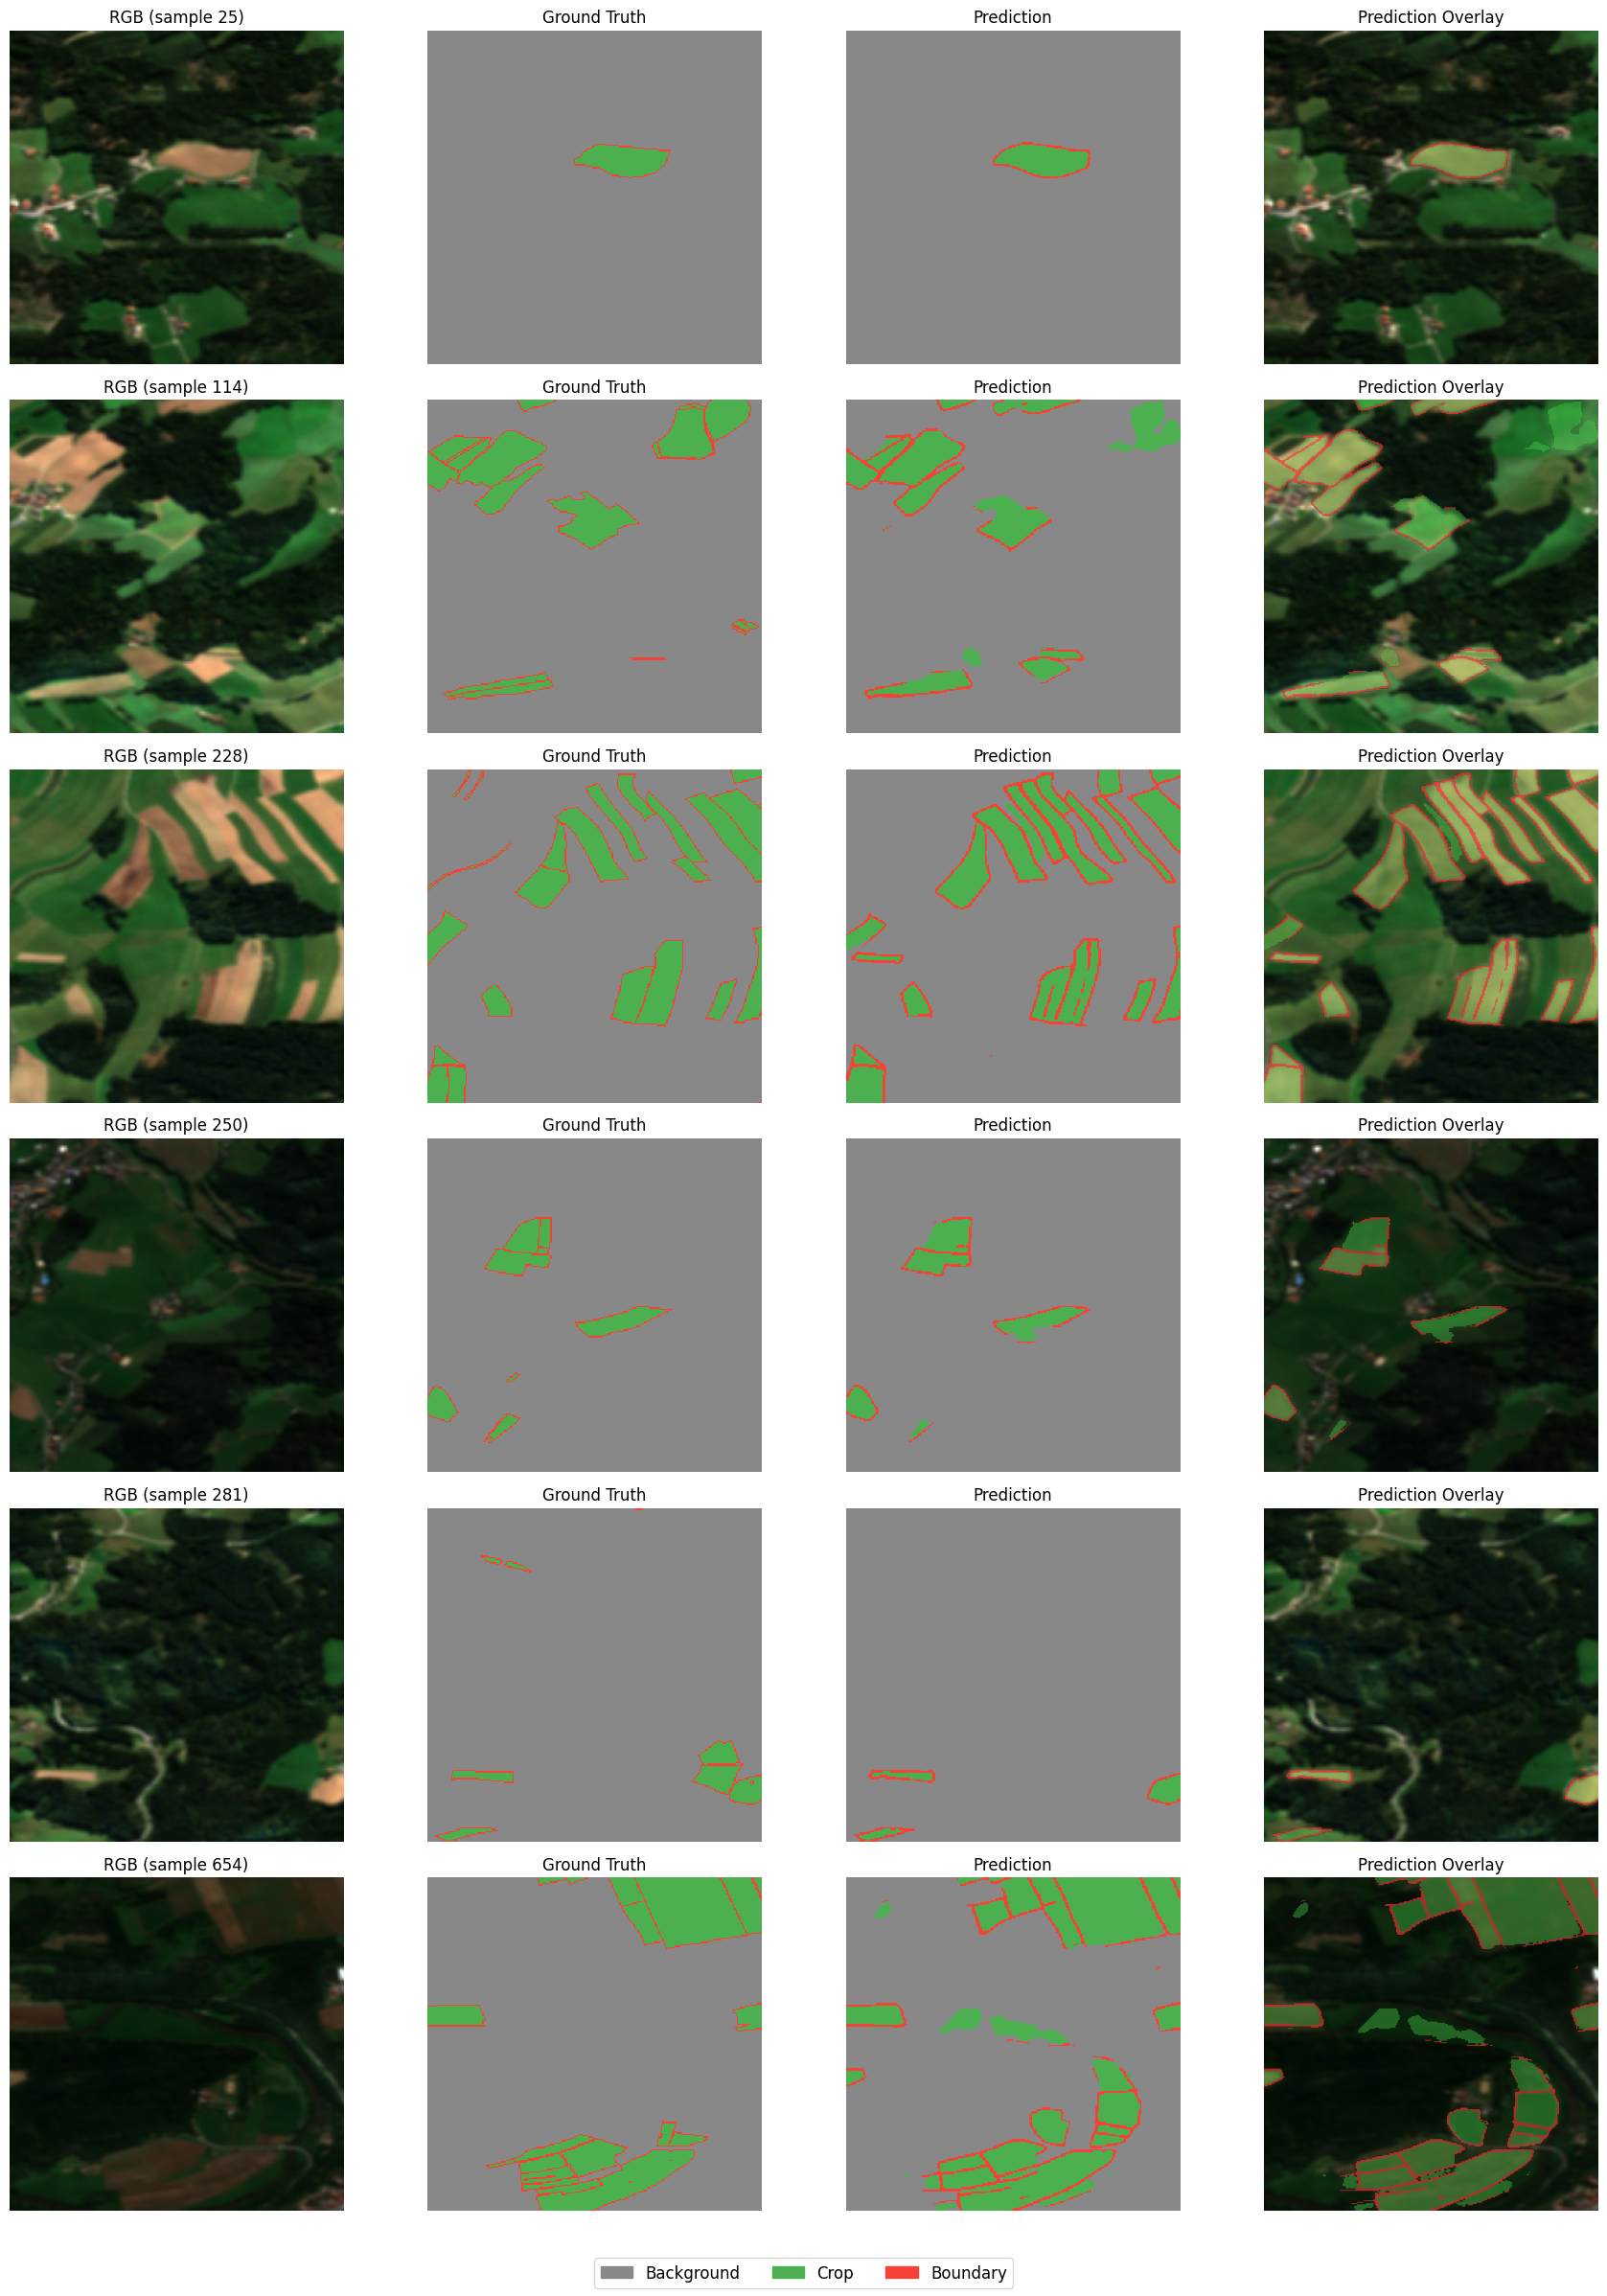

In [4]:
plot_sample_predictions(
    ds, indices, 
    CHECKPOINT_FOR_TEST, TEST_DIR, CMAP
    )

## 3. Post-Processing

Morphological Cleaning: Remove components with few pixels and fill small holes.

Watershed/Connected Components: Use Watershed segmentation (or connected component analysis) to extract and separate distinct predicted field objects. 

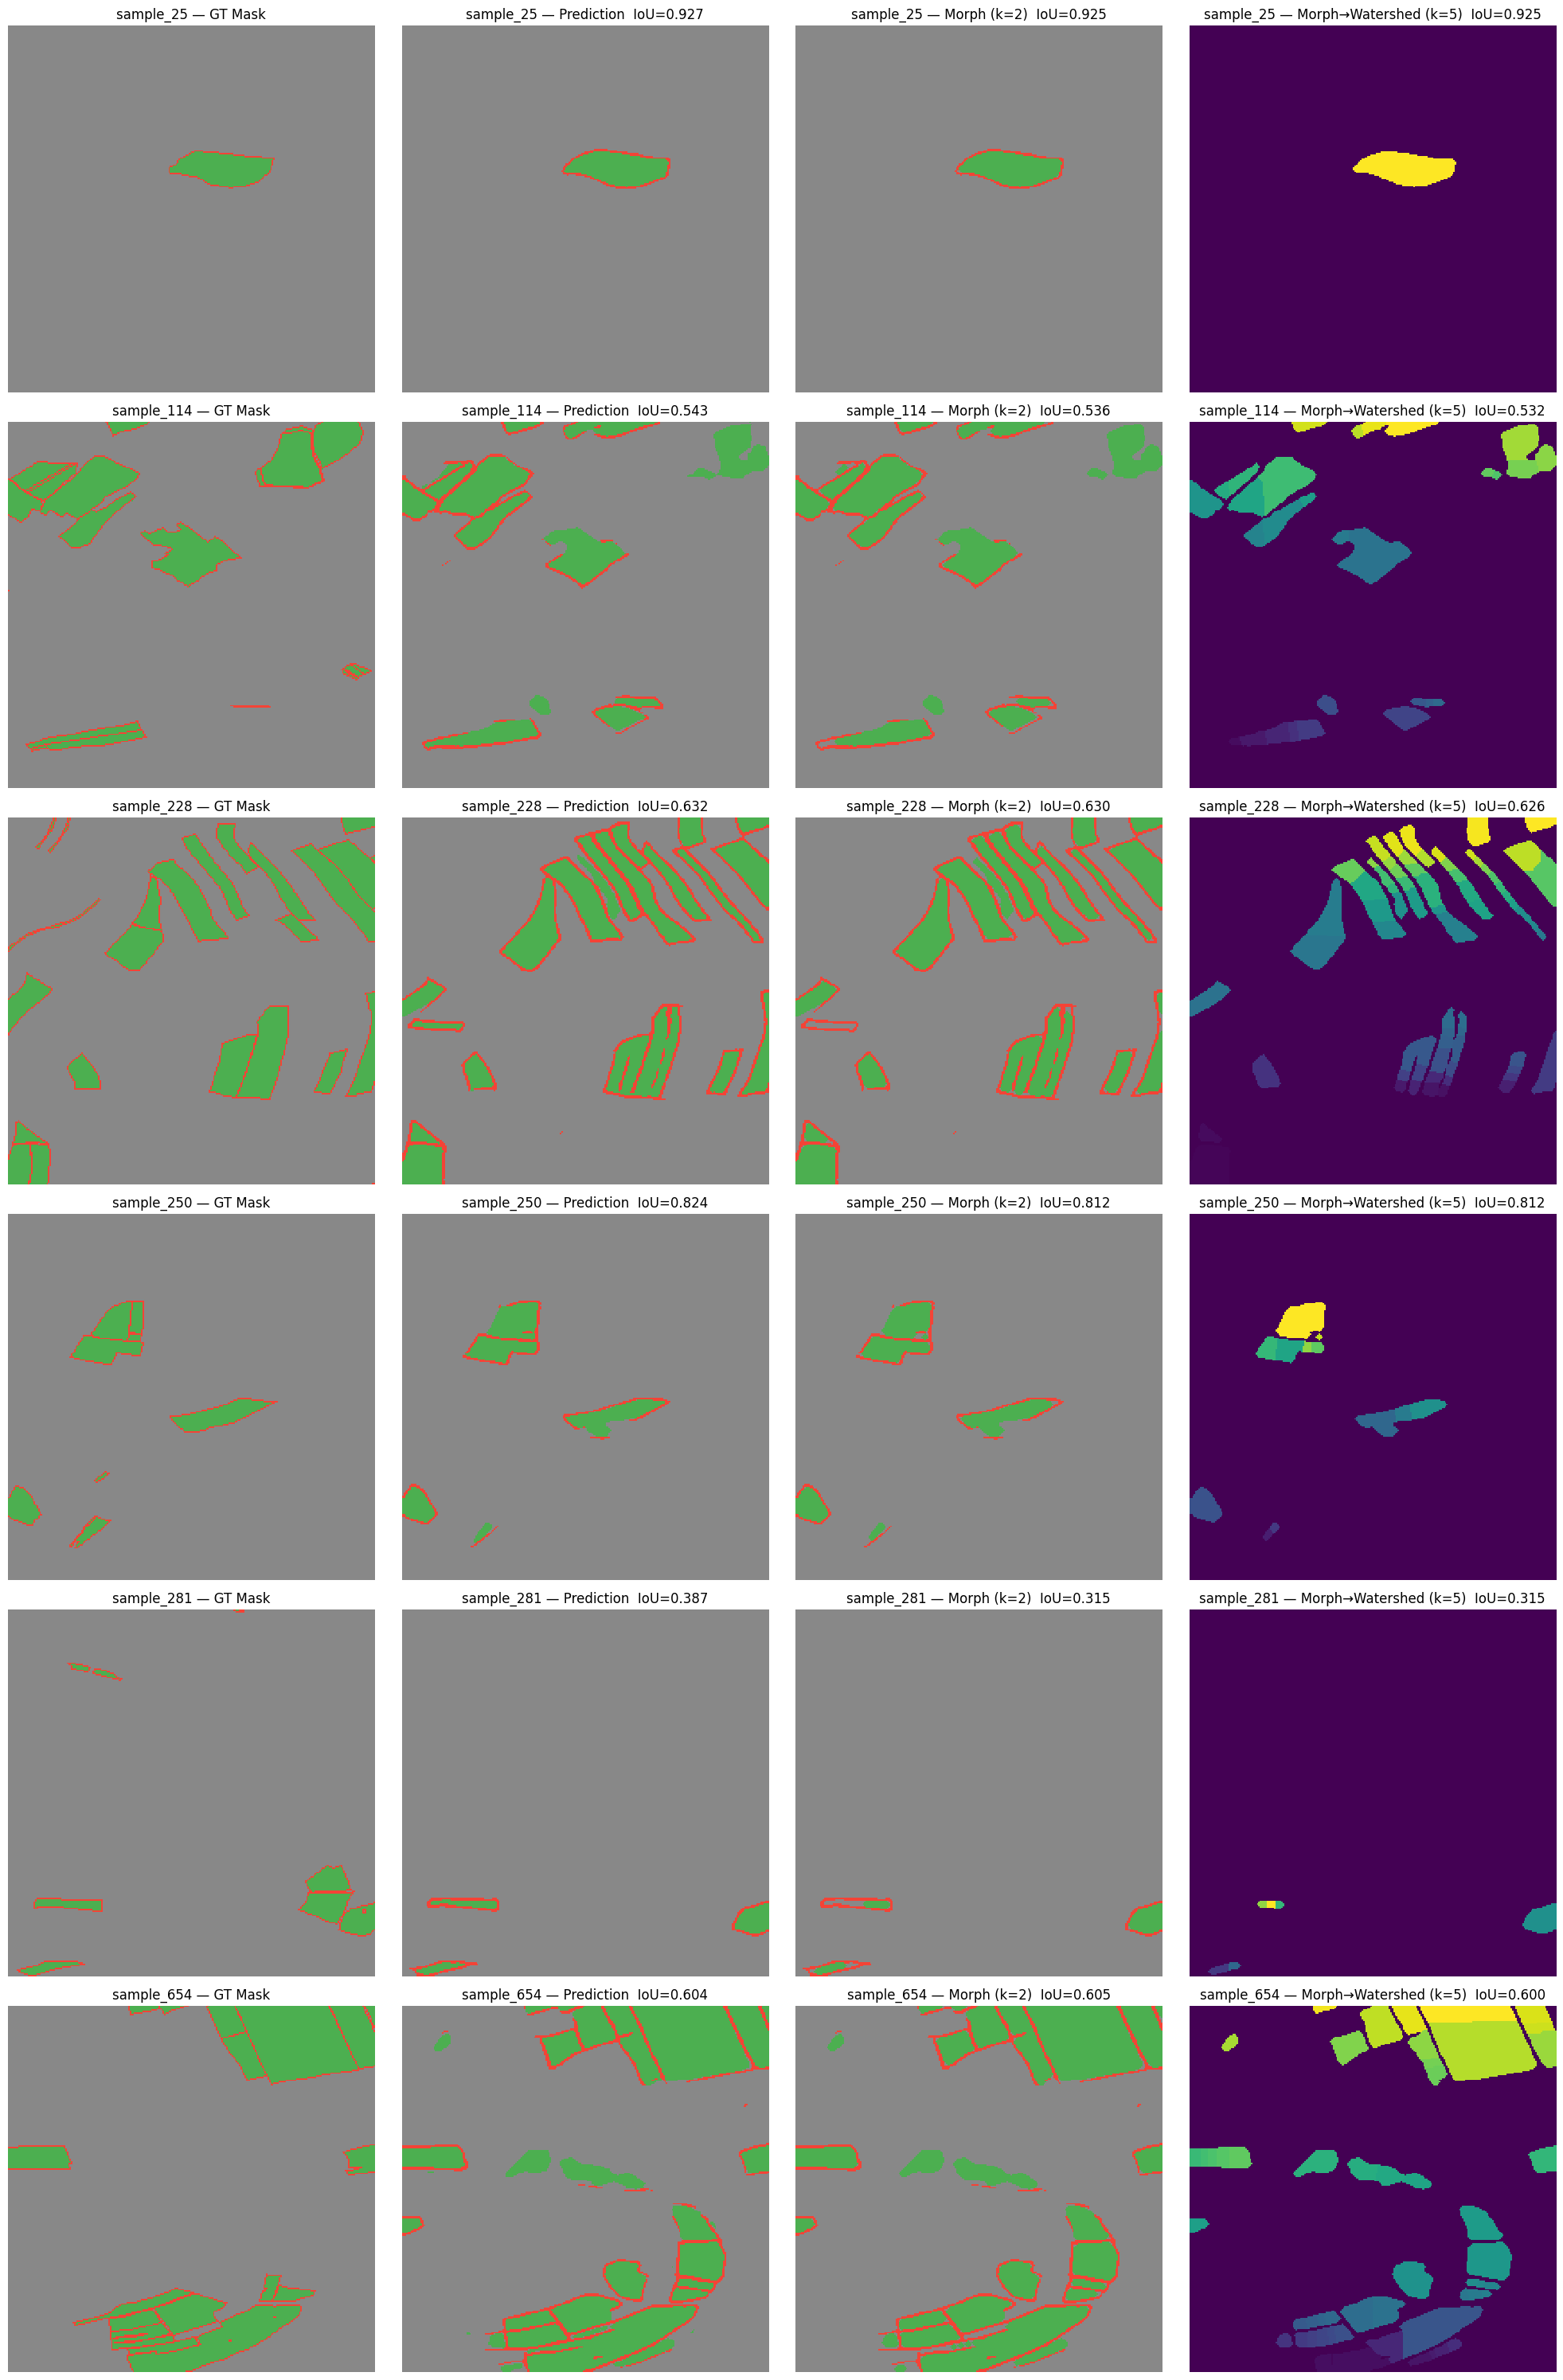

In [5]:
# post-process
morph_kernel_size = 2
watershed_kernel_size = 5
plot_post_processing_results(
    TEST_DIR, CMAP, 
    morph_kernel=morph_kernel_size, 
    watershed_kernel=watershed_kernel_size,
    chain=True
    )

## 4. Polygonization: Raster to Vector

Polygonizes each per-sample prediction TIF and shows raster + polygons side-by-side.

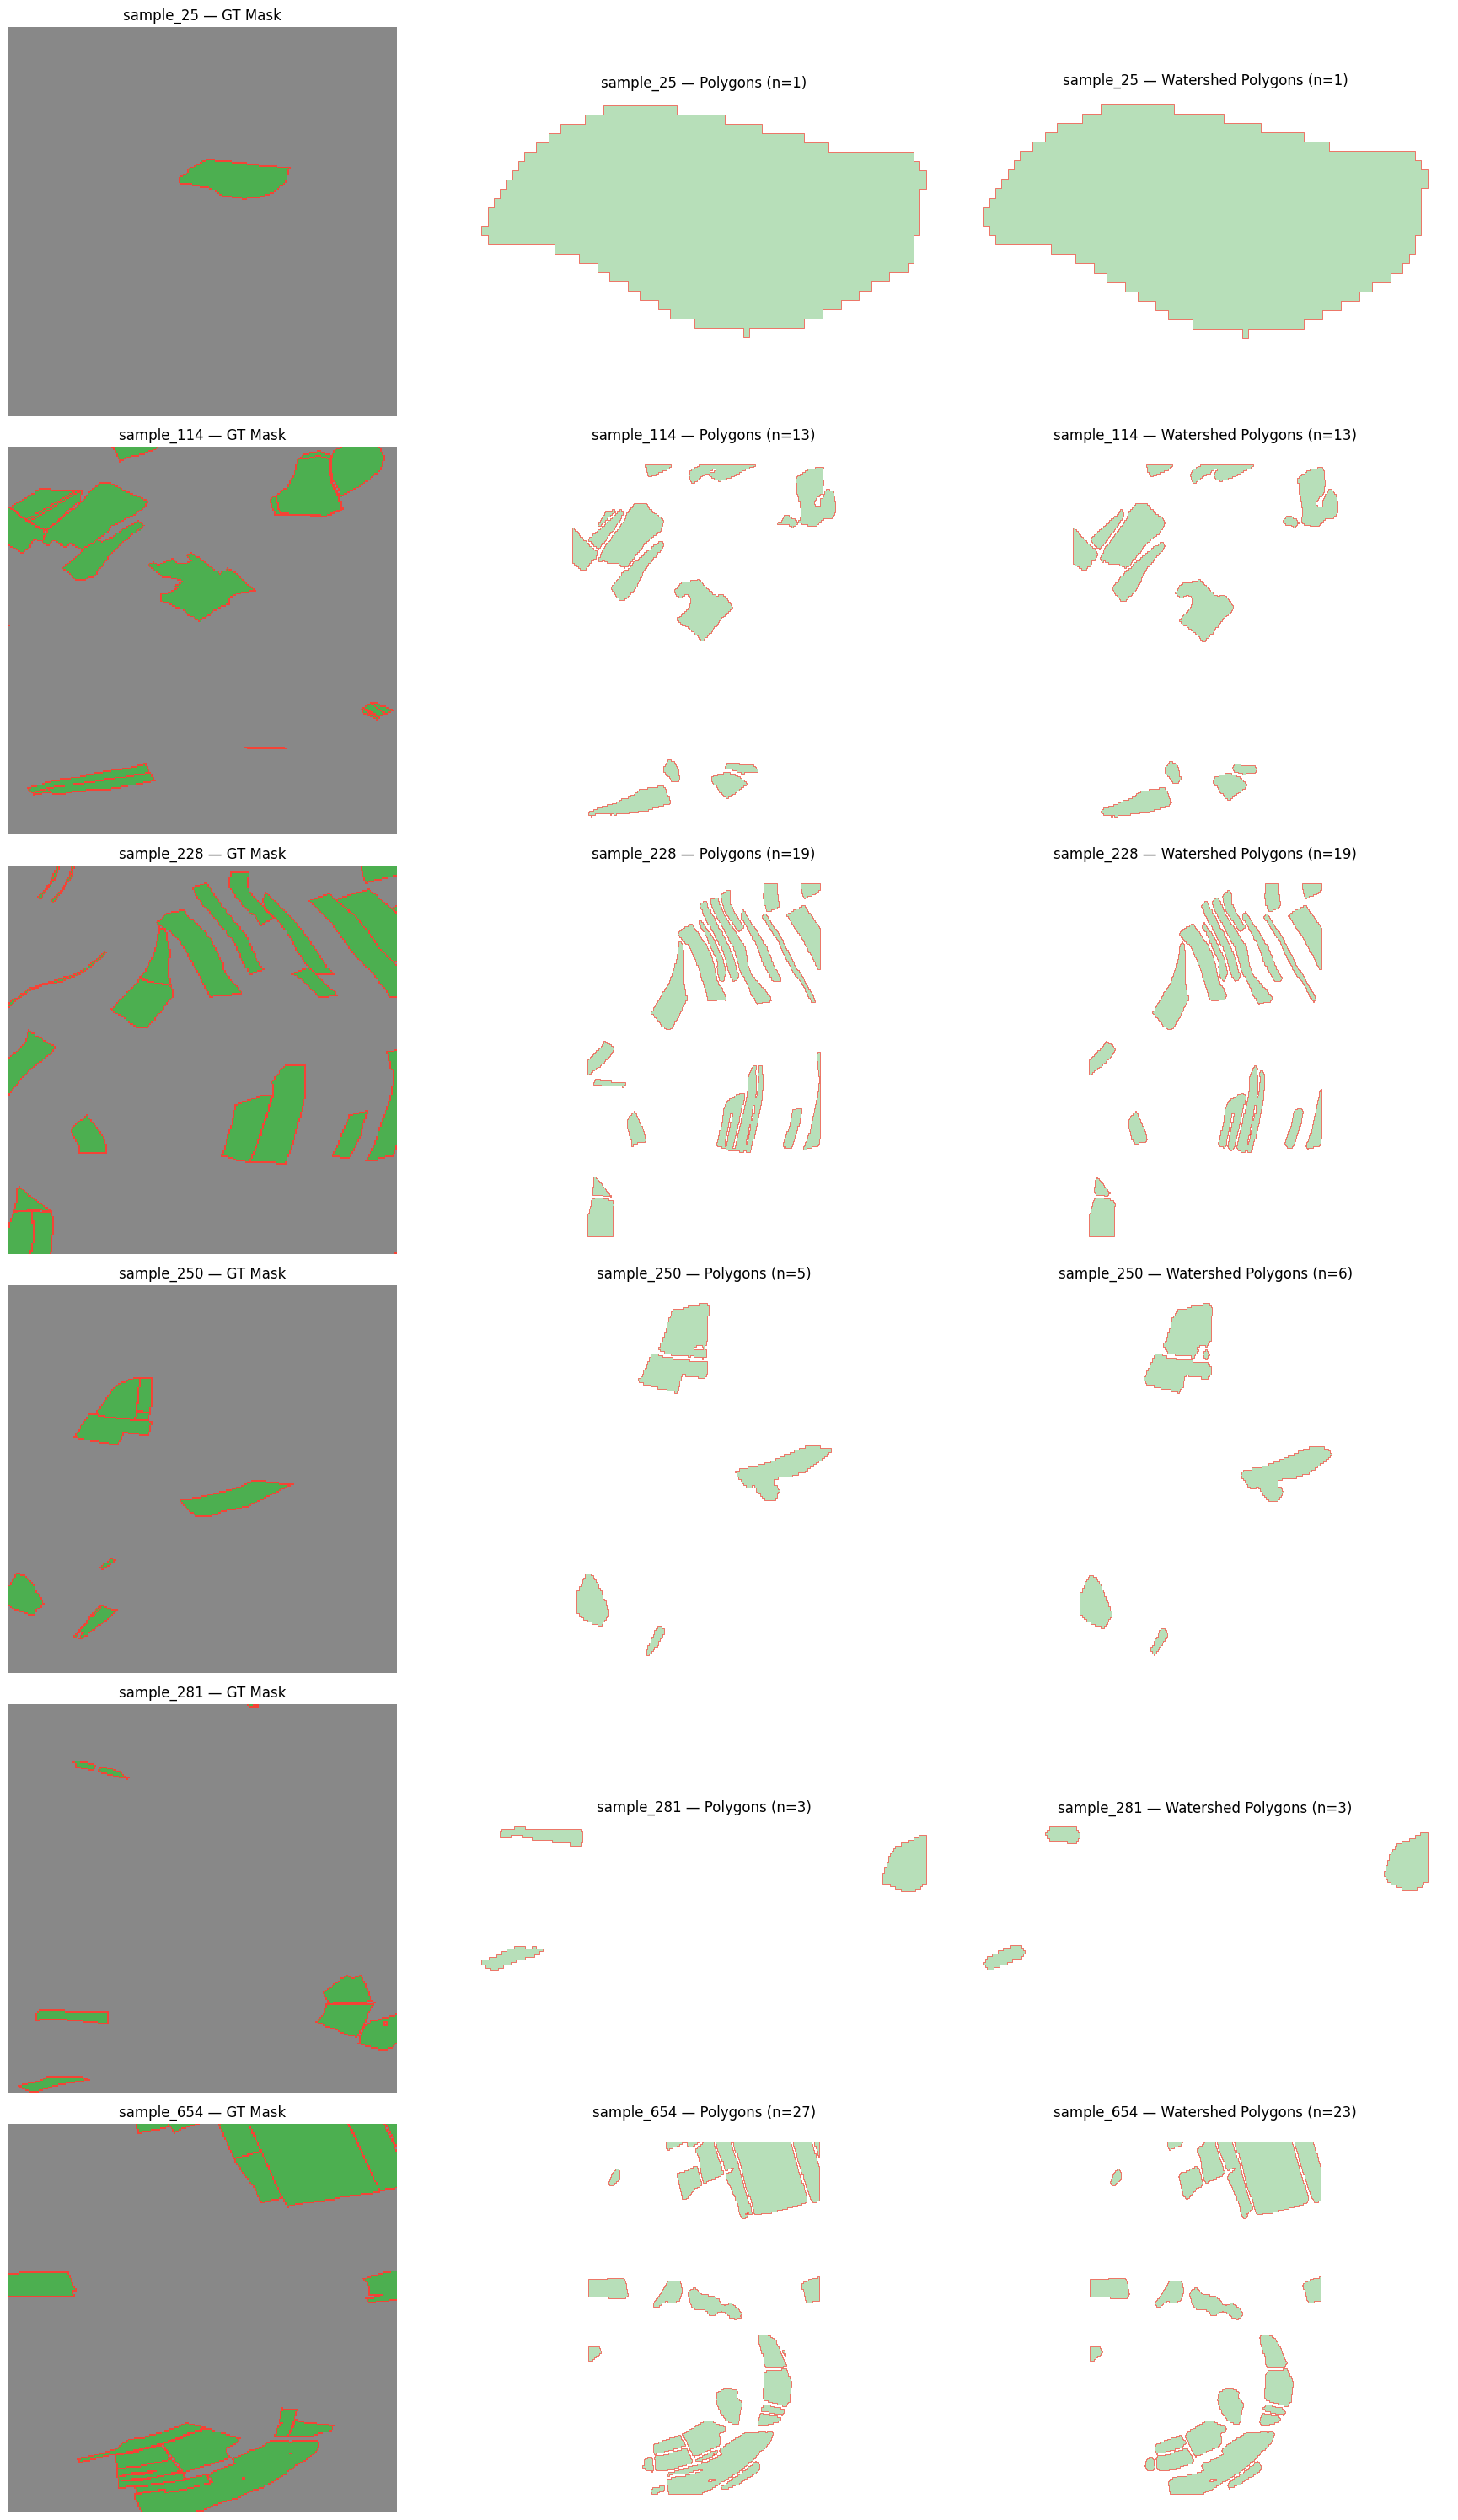

In [6]:
plot_polygonized_results(
    TEST_DIR, CMAP, simplify=0, min_size=200, postprocess="watershed"
    )

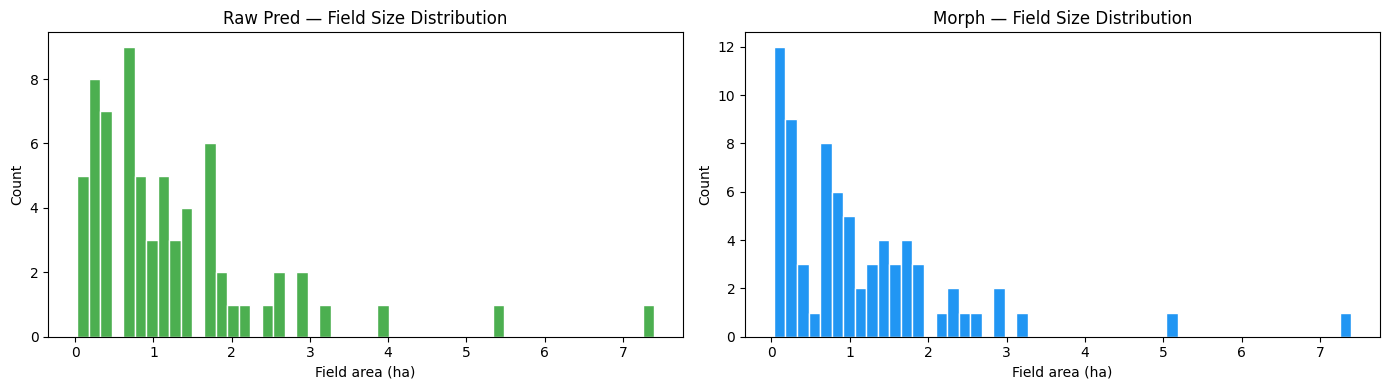

Raw pred: Total=68  Median=0.92 ha  Mean=1.25 ha  Max=7.40 ha
Morph: Total=73  Median=0.87 ha  Mean=1.13 ha  Max=7.39 ha


In [7]:
plot_polygon_size_distribution(TEST_DIR, "morph")